In [1]:
print(R.version$version.string)

[1] "R version 4.6.1 (2026-06-24 ucrt)"


In [2]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("readxl")
})

In [5]:
elopomorph_tree <- ape::read.tree("../../R/thirdparty/Phylogenetic Comparative Methods in R/8/elopomorph.tre") # just 61 species
elopomorph <- read.csv("../../R/thirdparty/Phylogenetic Comparative Methods in R/8/elopomorph.csv")
colnames(elopomorph) <- c("species", "feedmode", "maxtl")

stopifnot(all(elopomorph$species %in% elopomorph_tree$tip.label))
elopomorph <- elopomorph[match(elopomorph_tree$tip.label, elopomorph$species), ] # name match the dataset
stopifnot(all(elopomorph$species == elopomorph_tree$tip.label))

In [10]:
elopomorph$feedmode |> table()


   bite suction 
     31      30 

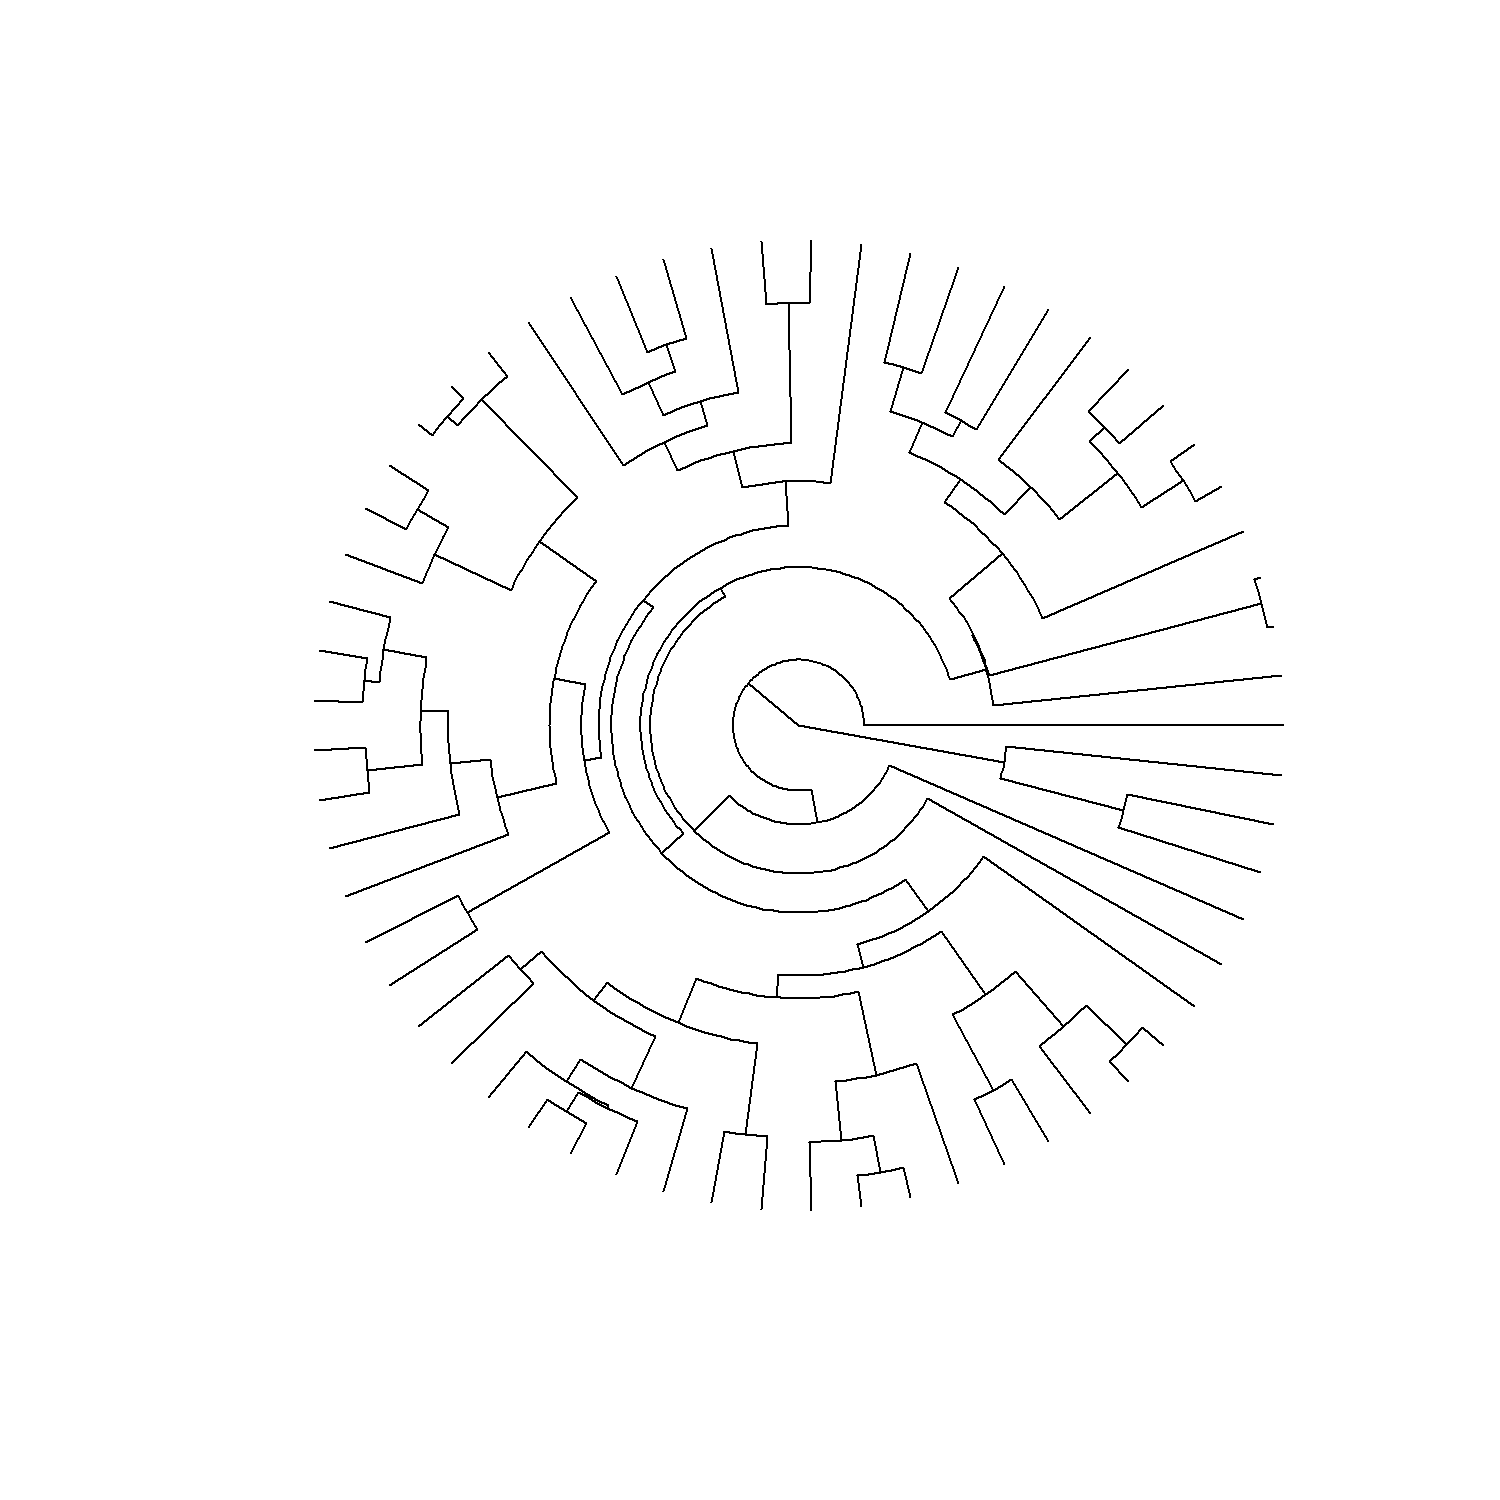

In [32]:
options(repr.plot.width = 6, repr.plot.height = 6, repr.plot.res = 250)
plot(elopomorph_tree, type = "fan", show.tip.label = FALSE)
ape::tiplabels(tip = elopomorph[elopomorph$feedmode == "bite", "species"], col = "red", pch=21, cex = 3)
ape::tiplabels(tip = elopomorph[elopomorph$feedmode == "suction", "species"], col = "blue", pch=21, cex = 3, adj = 1)

In [33]:
seq_along(elopomorph_tree$tip.label)

[1]  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
[26] 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50
[51] 51 52 53 54 55 56 57 58 59 60 61

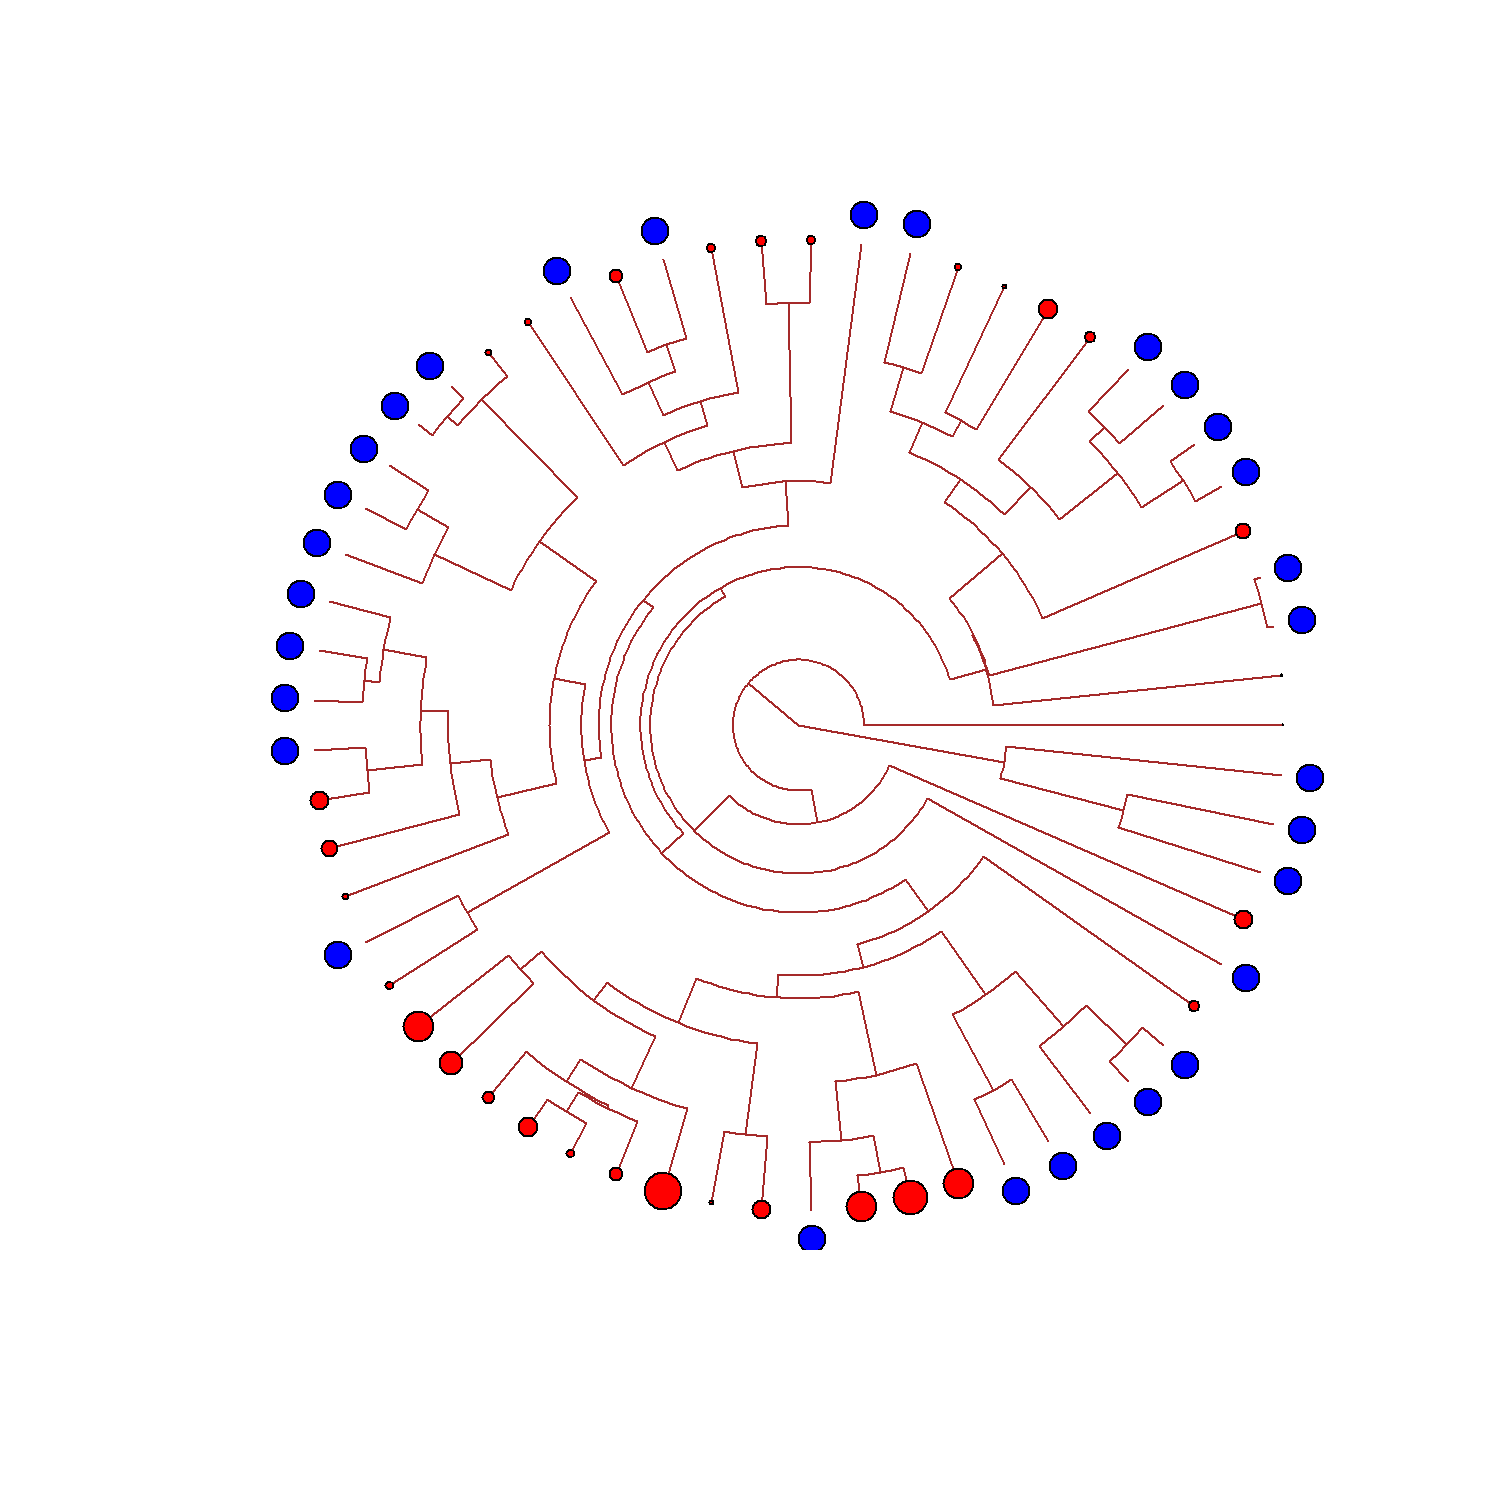

In [34]:
ape::plot.phylo(x = elopomorph_tree, type = "fan", show.tip.label = FALSE, show.node.label = FALSE, edge.color = "brown")
ape::tiplabels(tip = seq_along(elopomorph_tree$tip.label)[elopomorph$feedmode == "bite"], bg = "red", pch=21,
               cex = scale(elopomorph$maxtl[elopomorph$feedmode == "bite"], center = FALSE)) # the tip argument is tip number not id!!!
ape::tiplabels(tip = seq_along(elopomorph_tree$tip.label)[elopomorph$feedmode == "suction"], bg = "blue", pch=21, cex = 1.5, offset = 6)

In [63]:
# code from - https://r-graph-gallery.com/130-ring-or-donut-chart.html

doughnut <- function (x, labels = names(x), edges = 200, outer.radius = 0.8, inner.radius = 0.6, clockwise = FALSE, init.angle = if (clockwise) 90 else 0, density = NULL, 
                        angle = 45, col = NULL, border = FALSE, lty = NULL, main = NULL, new = FALSE, ...) 
                    {
    
                        if (!is.numeric(x) || any(is.na(x) | x < 0)) stop("'x' values must be positive.")
    
                        if (is.null(labels)) labels <- as.character(seq_along(x))
                        else labels <- as.graphicsAnnot(labels)
    
                        x <- c(0, cumsum(x)/sum(x))
                        dx <- diff(x)
                        nx <- length(dx)
                        
                        if (new) plot.new()
                        
                        pin <- par("pin")
                        xlim <- ylim <- c(-1, 1)
                        
                        if (pin[1L] > pin[2L]) xlim <- (pin[1L]/pin[2L]) * xlim
                        else ylim <- (pin[2L]/pin[1L]) * ylim
                        
                        plot.window(xlim, ylim, "", asp = 1)
                        if (is.null(col))
                            col <- if (is.null(density)) palette() else par("fg")
                                
                        col <- rep(col, length.out = nx)
                        border <- rep(border, length.out = nx)
                        lty <- rep(lty, length.out = nx)
                        angle <- rep(angle, length.out = nx)
                        density <- rep(density, length.out = nx)
                        twopi <- if (clockwise) -2 * pi else 2 * pi
                        
                        t2xy <- function(t, radius) {
                            t2p <- twopi * t + init.angle * pi/180
                            list(x = radius * cos(t2p), y = radius * sin(t2p))
                        }
                        
                        for (i in 1L:nx) {
                            
                            n <- max(2, floor(edges * dx[i]))
                            P <- t2xy(seq.int(x[i], x[i + 1], length.out = n), outer.radius)
                            polygon(c(P$x, 0), c(P$y, 0), density = density[i], angle = angle[i], border = border[i], col = col[i], lty = lty[i])
                            Pout <- t2xy(mean(x[i + 0:1]), outer.radius)
                            lab <- as.character(labels[i])
                            
                            if (!is.na(lab) && nzchar(lab)) {
                                lines(c(1, 1.05) * Pout$x, c(1, 1.05) * Pout$y) # lines for slice labels
                                text(1.1 * Pout$x, 1.1 * Pout$y, labels[i], xpd = TRUE, adj = ifelse(Pout$x < 0, 1, 0), ...) # slice labels
                            }
                            
                            # the inner white disc     
                            Pin <- t2xy(seq.int(0, 1, length.out = n*nx), inner.radius)
                            polygon(Pin$x, Pin$y, density = NA, angle = angle[i], border = NA, lty = lty[i], col = "white")
                        }
                    
                        title(main = main, ...)
                        invisible(NULL)
}

In [218]:
elopomorph$feedmode

[1] "bite"    "bite"    "suction" "suction" "bite"    "suction" "suction"
 [8] "suction" "suction" "bite"    "bite"    "bite"    "bite"    "suction"
[15] "suction" "bite"    "bite"    "bite"    "suction" "bite"    "suction"
[22] "bite"    "bite"    "suction" "suction" "suction" "suction" "suction"
[29] "suction" "suction" "suction" "suction" "bite"    "bite"    "bite"   
[36] "suction" "bite"    "bite"    "bite"    "bite"    "bite"    "bite"   
[43] "bite"    "bite"    "bite"    "bite"    "suction" "bite"    "bite"   
[50] "bite"    "suction" "suction" "suction" "suction" "suction" "bite"   
[57] "suction" "bite"    "suction" "suction" "suction"

In [141]:
rle(elopomorph$feedmode)$length / length(elopomorph$feedmode)

[1] 0.03278689 0.03278689 0.01639344 0.06557377 0.06557377 0.03278689
 [7] 0.04918033 0.01639344 0.01639344 0.01639344 0.03278689 0.14754098
[13] 0.04918033 0.01639344 0.16393443 0.01639344 0.04918033 0.08196721
[19] 0.01639344 0.01639344 0.01639344 0.04918033

In [143]:
FEEDMODE_COLOURS <- c(bite = rgb(0.5, 0, 0, 0.2), suction = rgb(0.45, 0.75, 1, 0.2))

Warning message in rep(lty, length.out = nx):
"'x' is NULL so the result will be NULL"
Warning message in rep(density, length.out = nx):
"'x' is NULL so the result will be NULL"


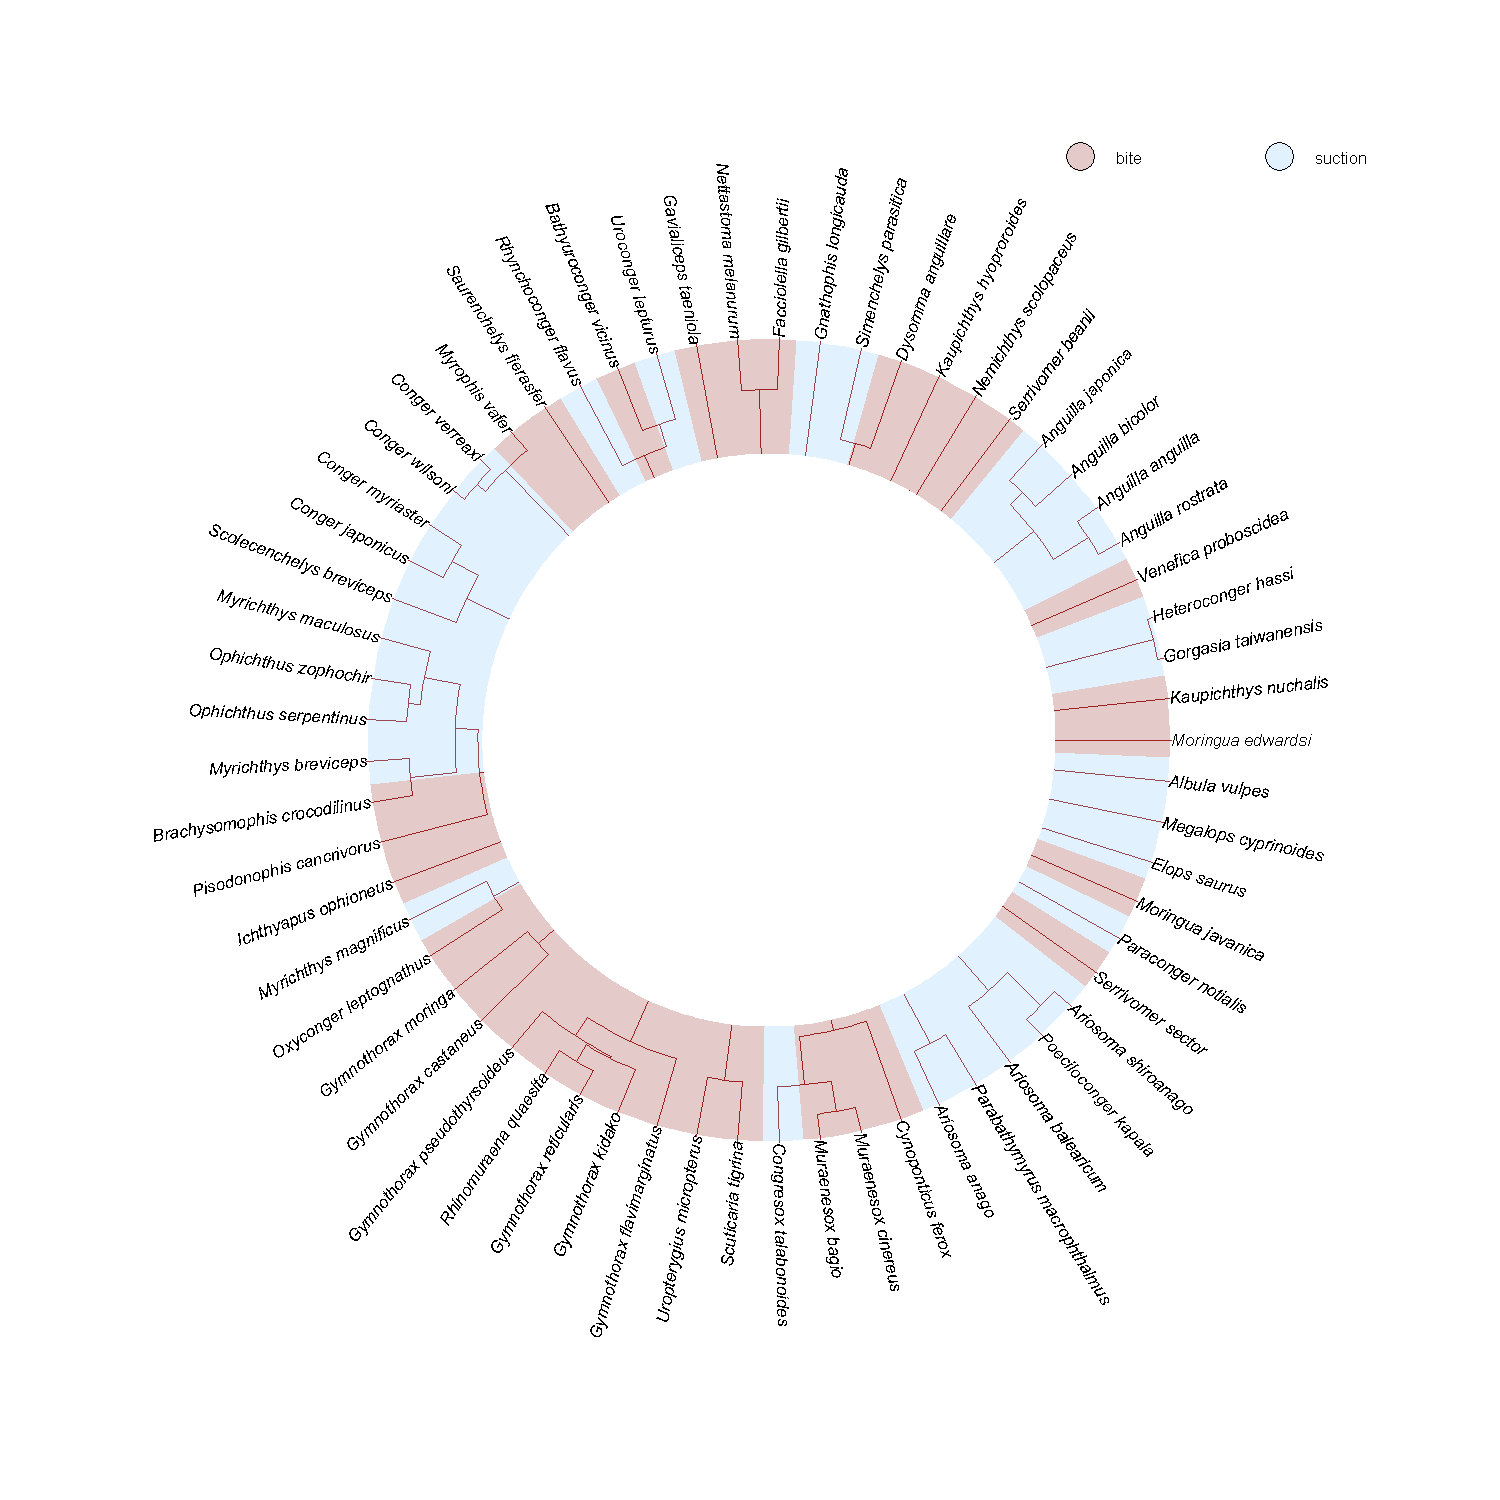

In [283]:
ape::plot.phylo(x = elopomorph_tree, type = "fan", show.tip.label = TRUE, show.node.label = FALSE, edge.color = "brown")

doughnut(rle(elopomorph$feedmode)$length / length(elopomorph$feedmode), inner.radius=0.5, outer.radius = 0.7, col=FEEDMODE_COLOURS[rle(elopomorph$feedmode)$values], init.angle = -2.5)
legend("topright", legend = names(FEEDMODE_COLOURS), pt.bg = FEEDMODE_COLOURS, pch = 21, pt.cex = 4, horiz = FALSE, ncol = 2, bty = "n", y.intersp = 0.45)

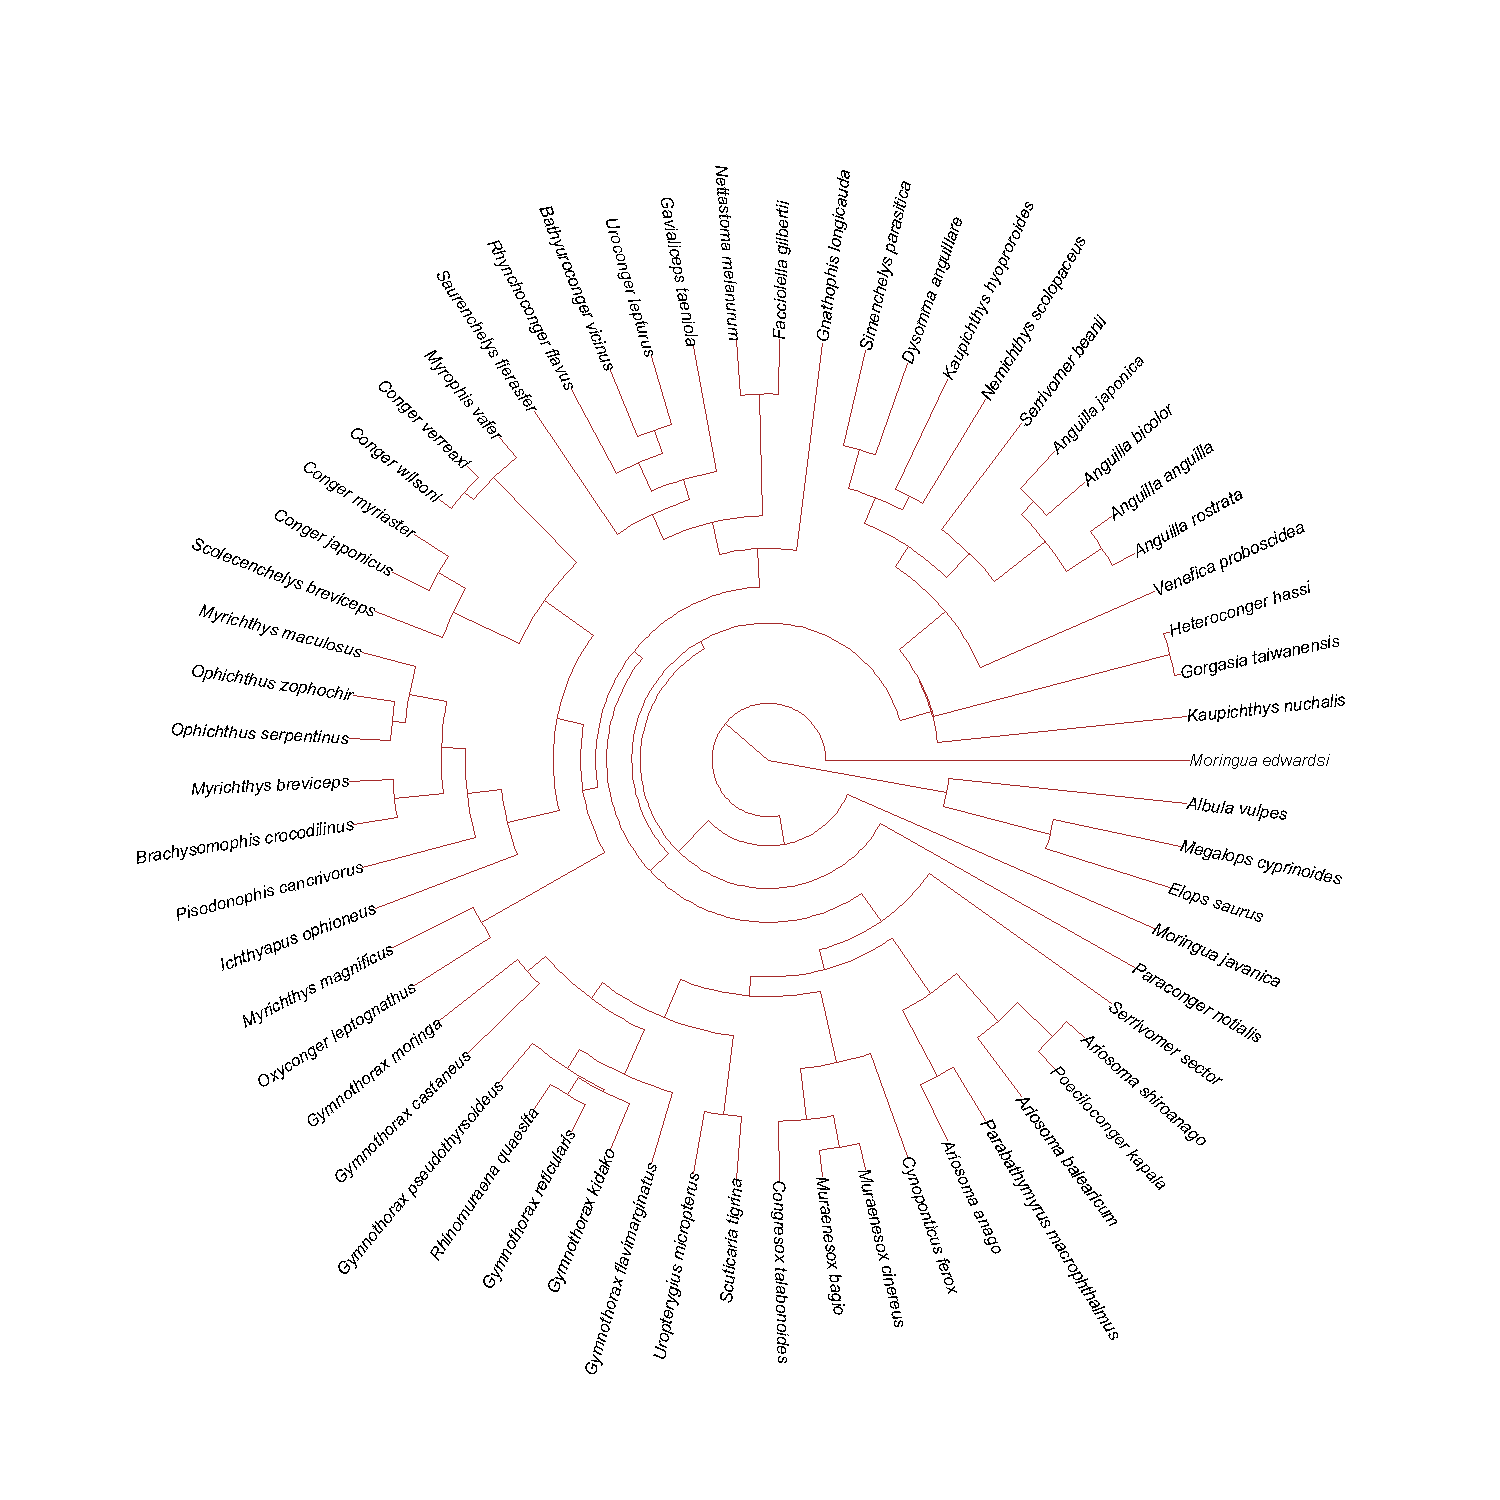

In [301]:
# ylim???

ape::plot.phylo(x = elopomorph_tree, type = "fan", show.tip.label = TRUE, show.node.label = FALSE, edge.color = "brown", y.lim = c(-0.75, 10))

In [308]:
ape::plot.phylo(x = elopomorph_tree, type = "fan", show.tip.label = TRUE, show.node.label = FALSE, edge.color = "brown", asp = 1.5)

ERROR: Error in plot.default(0, type = "n", xlim = x.lim, ylim = y.lim, xlab = "", : formal argument "asp" matched by multiple actual arguments


In [282]:
head(elopomorph)

,species,feedmode,maxtl
,<chr>,<chr>,<dbl>
34,Moringua_edwardsi,bite,15.0
32,Kaupichthys_nuchalis,bite,16.0
22,Gorgasia_taiwanensis,suction,74.1
29,Heteroconger_hassi,suction,40.0
61,Venefica_proboscidea,bite,100.0
5,Anguilla_rostrata,suction,152.0


Warning message in rep(lty, length.out = nx):
"'x' is NULL so the result will be NULL"
Warning message in rep(density, length.out = nx):
"'x' is NULL so the result will be NULL"


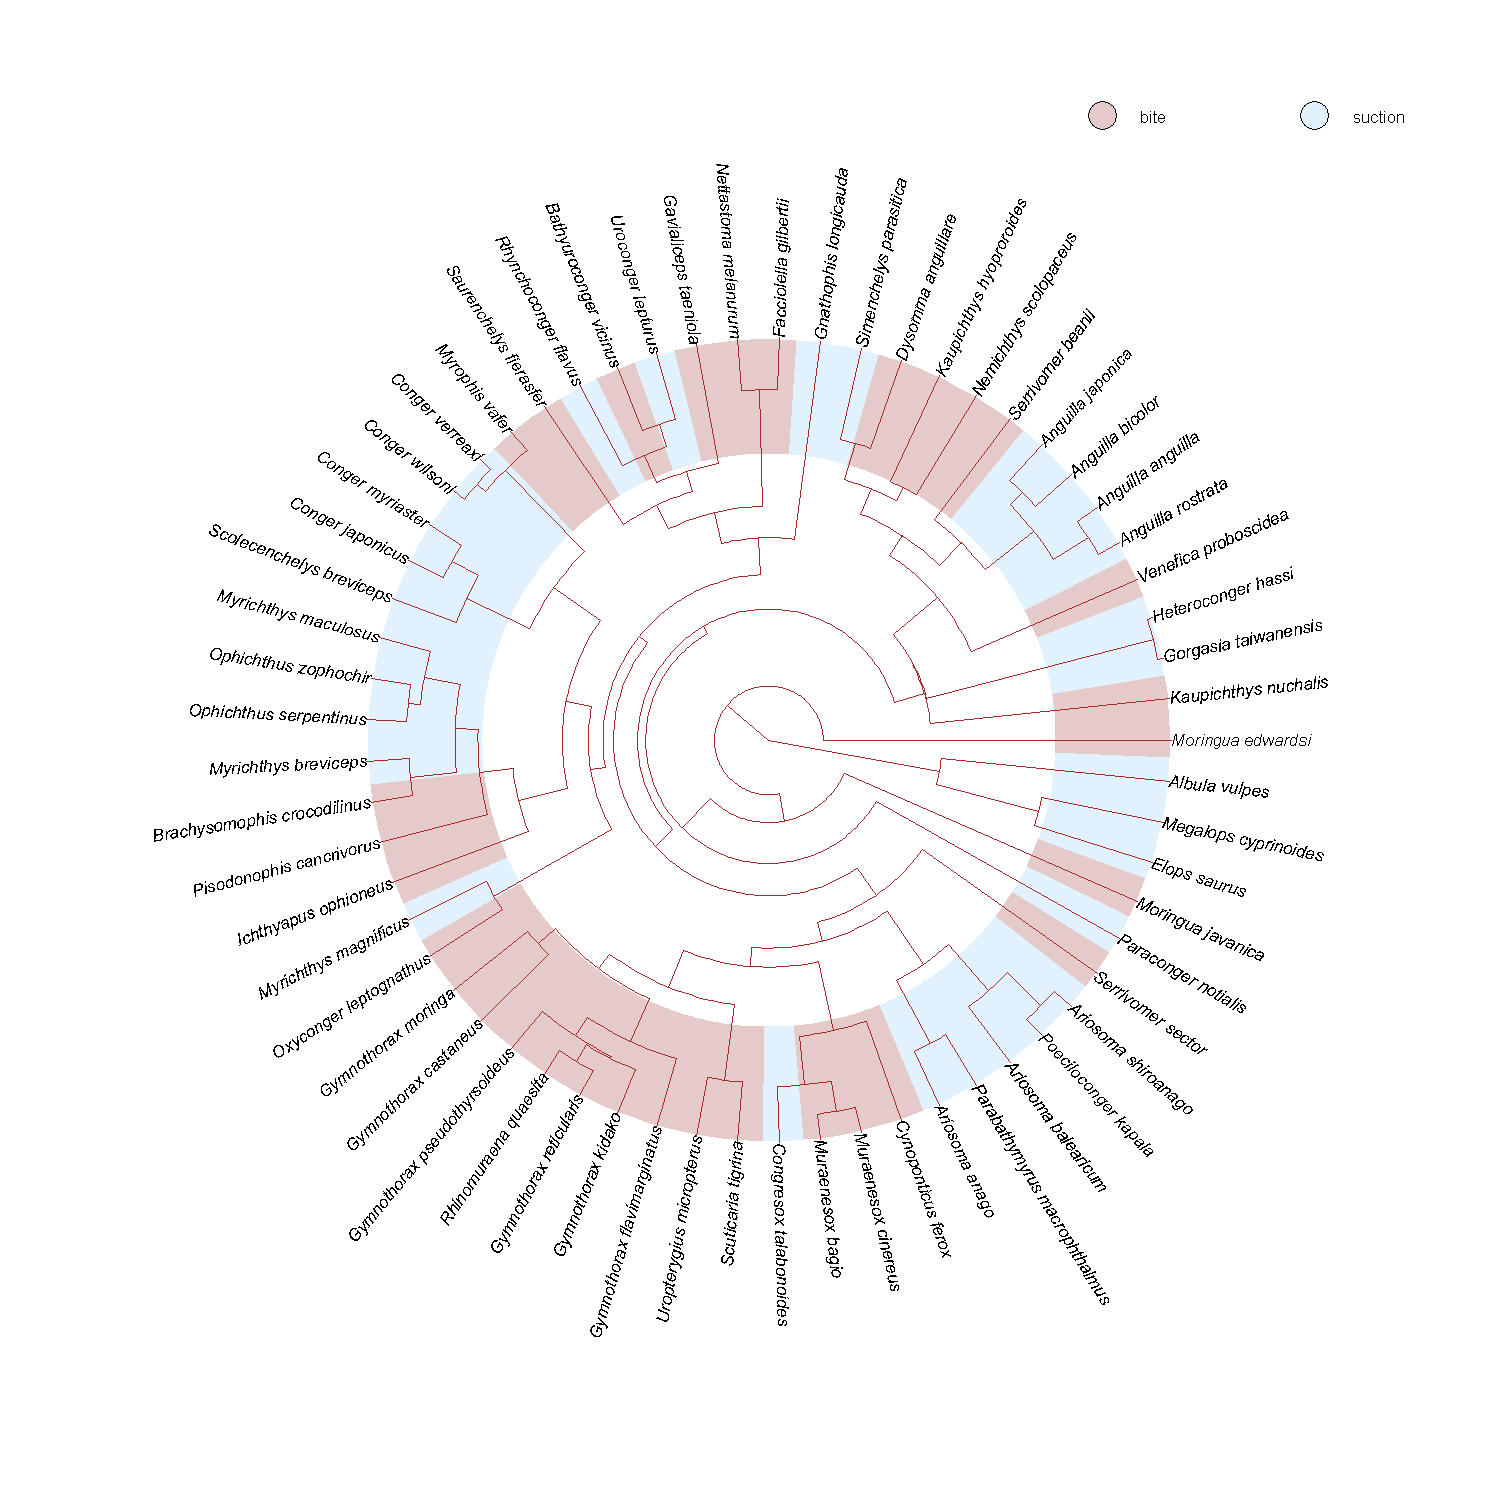

In [286]:
# the issue with plotting the doughnut chart after the phylogeny is that we cannot hace the inner circle white - this will hide the deep branches of the phylogeny
# first plot the doughnut chart and then overlay the phylogeny on top???
# is this possible to do??
# https://stackoverflow.com/questions/18262017/why-does-plot-not-respect-add-true

doughnut(rle(elopomorph$feedmode)$length / length(elopomorph$feedmode), inner.radius=0.5, outer.radius = 0.7, col=FEEDMODE_COLOURS[rle(elopomorph$feedmode)$values], init.angle = -2.5, new = TRUE)
par(new=TRUE)
ape::plot.phylo(x = elopomorph_tree, type = "fan", show.tip.label = TRUE, show.node.label = FALSE, edge.color = "brown")
legend("topright", legend = names(FEEDMODE_COLOURS), pt.bg = FEEDMODE_COLOURS, pch = 21, pt.cex = 4, horiz = FALSE, ncol = 2, bty = "n", y.intersp = 0.45)

## ___FRED 4.0 phylogeny___
------------------

In [3]:
phylogeny <- ape::read.tree("../../data/chapter2/uphylomaker/FRED4_1301.tre")
data <- readxl::read_excel("../../data/chapter2/FRED/subsets/final.xlsx", sheet = "final")
data$binominal <- gsub(data$binominal, pattern = ' ', replacement = '_')
stopifnot(all(data$binominal %in% phylogeny$tip.label))

data <- data[match(phylogeny$tip.label, data$binominal), ] # name match the dataset with the phylogeny
stopifnot(all(data$binominal == phylogeny$tip.label))

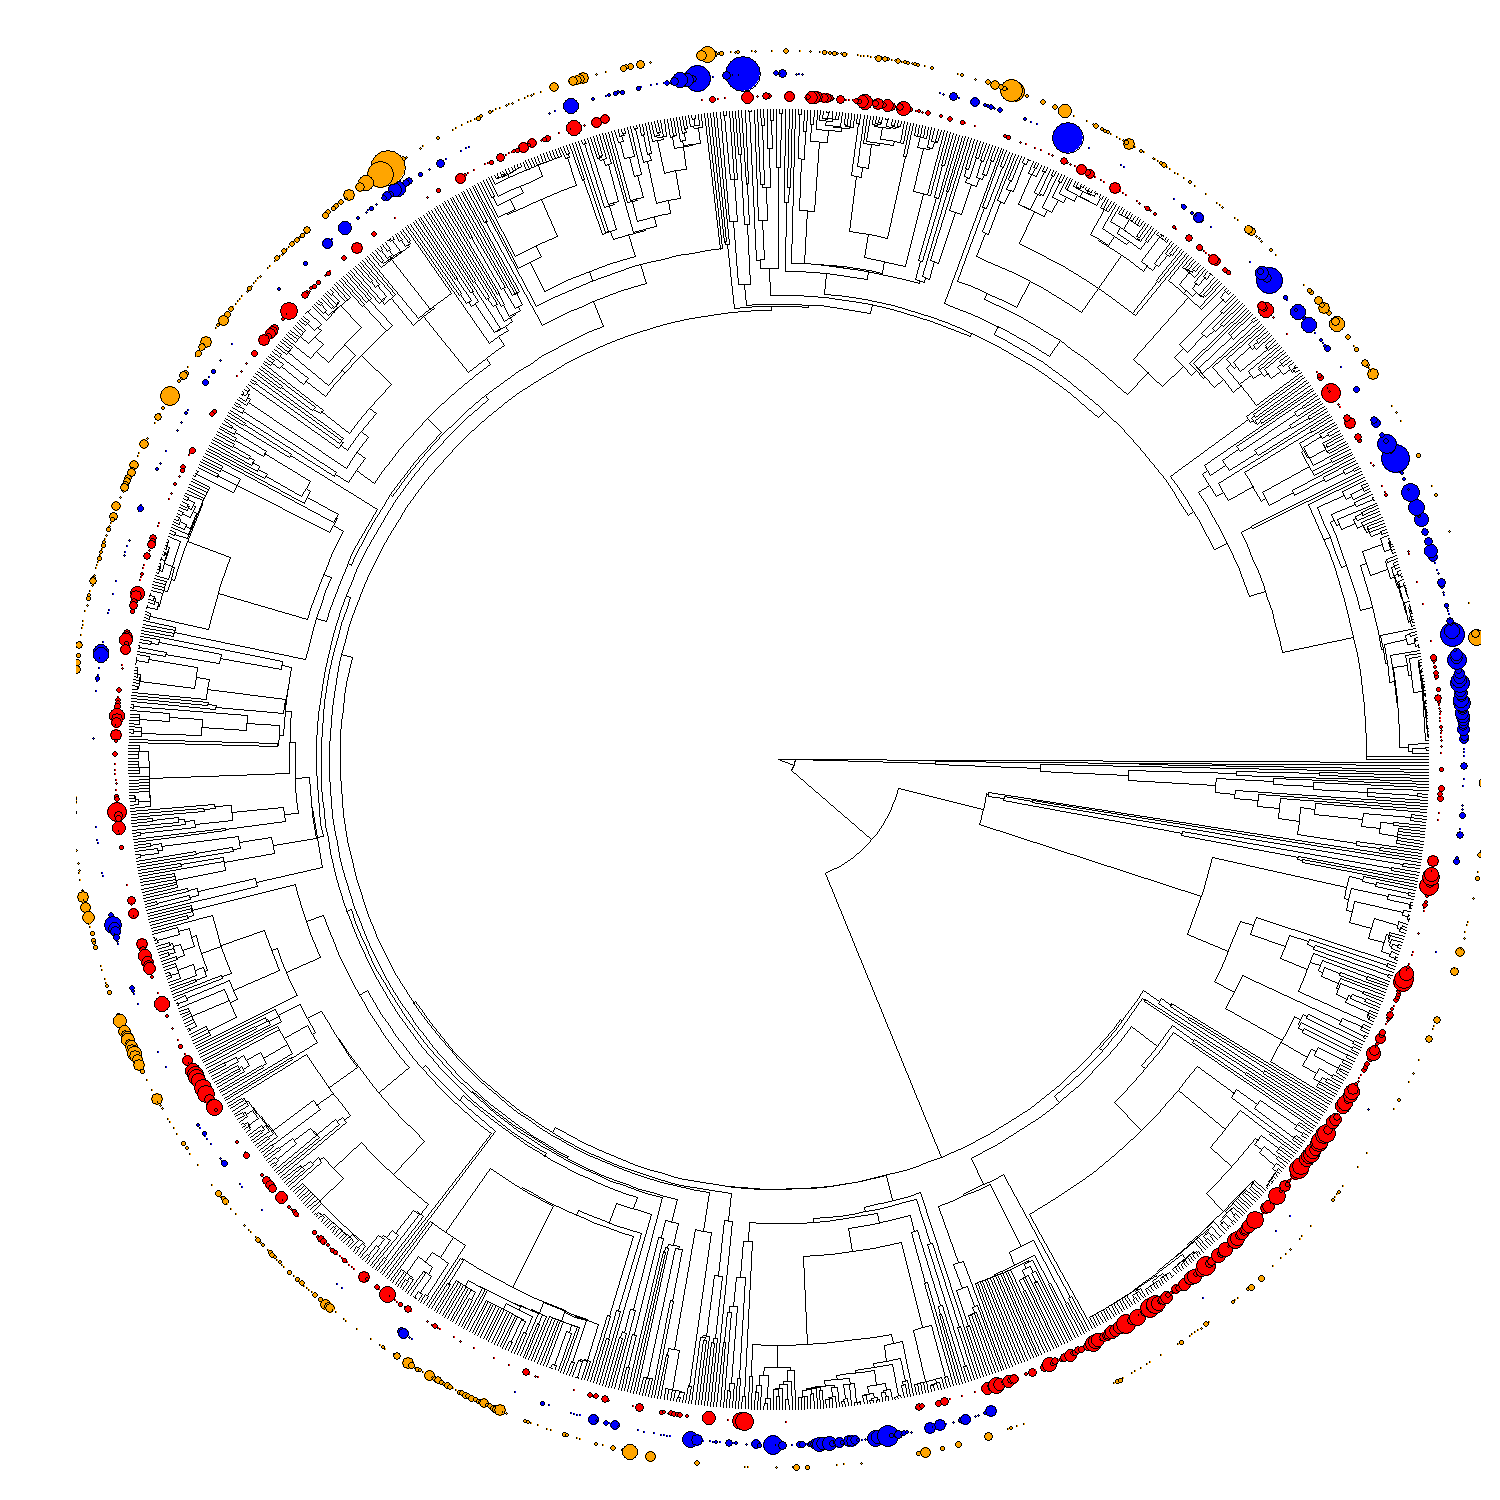

In [46]:
# png("../../plots/phylogeny.png", width = 20, height = 20, units = "in", res = 500)
par(mar = c(1, 4, 2, 1), oma = c(0, 0, 0, 0))
options(repr.plot.width = 15, repr.plot.height = 15, repr.plot.res = 100)

ape::plot.phylo(x = phylogeny, lwd = 1, type = "fan", show.tip.label = FALSE, show.node.label = FALSE)

SPACING_FIRST <- 8

# if we want to see all the species set center argument of scale() to FALSE
ape::tiplabels(bg = "red", pch = 21, cex = scale(exp(data$F00679)), offset = SPACING_FIRST) # RD
ape::tiplabels(bg = "blue", pch = 21, cex = scale(exp(data$F00727)) / 1.5, offset = SPACING_FIRST + 14) # SRL
ape::tiplabels(bg = "orange", pch = 21, cex = scale(exp(data$F00709)) / 1.5, offset = SPACING_FIRST + 28) # RTD
# dev.off()

In [93]:
rle(data$state) # rle() gives you the count of consecutively occurring elements

Run Length Encoding
  lengths: int [1:68] 147 1 4 1 35 2 64 9 1 32 ...
  values : chr [1:68] "AM" "NMAM" "AM" "NM" "AM" "NMAM" "AM" "ErM" "EcM" "AM" "NMAM" ...

In [94]:
sum(rle(data$state)$lengths) # total should be 1301 :)

[1] 1301

In [95]:
# now let's convert this to %s

(rle(data$state)$length / 1301) # %s of the RLE

[1] 0.1129900077 0.0007686395 0.0030745580 0.0007686395 0.0269023828
 [6] 0.0015372790 0.0491929285 0.0069177556 0.0007686395 0.0245964643
[11] 0.0007686395 0.0299769408 0.0023059185 0.0007686395 0.0015372790
[16] 0.0015372790 0.0007686395 0.0007686395 0.0007686395 0.0269023828
[21] 0.0007686395 0.0084550346 0.0023059185 0.0906994620 0.0015372790
[26] 0.0153727902 0.0092236741 0.0007686395 0.0023059185 0.0015372790
[31] 0.0422751729 0.0053804766 0.0092236741 0.0553420446 0.0038431975
[36] 0.0092236741 0.0046118370 0.0038431975 0.0122982321 0.0868562644
[41] 0.0023059185 0.0353574174 0.0015372790 0.0115295926 0.0023059185
[46] 0.0076863951 0.0069177556 0.0023059185 0.0007686395 0.0230591852
[51] 0.0007686395 0.0107609531 0.0007686395 0.0023059185 0.0007686395
[56] 0.0153727902 0.0092236741 0.0768639508 0.0007686395 0.0361260569
[61] 0.0007686395 0.0422751729 0.0192159877 0.0184473482 0.0007686395
[66] 0.0092236741 0.0015372790 0.0007686395

In [96]:
rle(data$state)$values

[1] "AM"    "NMAM"  "AM"    "NM"    "AM"    "NMAM"  "AM"    "ErM"   "EcM"  
[10] "AM"    "NMAM"  "AM"    "NMAM"  "AM"    "NMAM"  "EcM"   "NMAM"  "AM"   
[19] "NMAM"  "AM"    "NM"    "AM"    "EcMAM" "AM"    "NMAM"  "AM"    "EcM"  
[28] "NMAM"  "EcM"   "AM"    "EcM"   "AM"    "EcMAM" "AM"    "NM"    "AM"   
[37] "EcM"   "AM"    "EcM"   "AM"    "EcMAM" "AM"    "EcMAM" "AM"    "NMAM" 
[46] "AM"    "NM"    "AM"    "NMAM"  "AM"    "NMAM"  "AM"    "NMAM"  "AM"   
[55] "NMAM"  "AM"    "NMAM"  "AM"    "NMAM"  "AM"    "NMAM"  "AM"    "EcM"  
[64] "AM"    "NMAM"  "AM"    "NMAM"  "AM"

In [99]:
STATE_COLOURS[rle(data$state)$values] # colour mapping

AM        NMAM          AM          NM          AM        NMAM 
"#FE9DCF26"   "#2D2E30" "#FE9DCF26"   "#11E823" "#FE9DCF26"   "#2D2E30" 
         AM         ErM         EcM          AM        NMAM          AM 
"#FE9DCF26"   "#6B6CF2"   "#23B9AF" "#FE9DCF26"   "#2D2E30" "#FE9DCF26" 
       NMAM          AM        NMAM         EcM        NMAM          AM 
  "#2D2E30" "#FE9DCF26"   "#2D2E30"   "#23B9AF"   "#2D2E30" "#FE9DCF26" 
       NMAM          AM          NM          AM       EcMAM          AM 
  "#2D2E30" "#FE9DCF26"   "#11E823" "#FE9DCF26"   "#E71A23" "#FE9DCF26" 
       NMAM          AM         EcM        NMAM         EcM          AM 
  "#2D2E30" "#FE9DCF26"   "#23B9AF"   "#2D2E30"   "#23B9AF" "#FE9DCF26" 
        EcM          AM       EcMAM          AM          NM          AM 
  "#23B9AF" "#FE9DCF26"   "#E71A23" "#FE9DCF26"   "#11E823" "#FE9DCF26" 
        EcM          AM         EcM          AM       EcMAM          AM 
  "#23B9AF" "#FE9DCF26"   "#23B9AF" "#FE9DCF26"   "#E71A23" "#FE9DCF26" 
      EcMAM          AM        NMAM          AM          NM          AM 
  "#E71A23" "#FE9DCF26"   "#2D2E30" "#FE9DCF26"   "#11E823" "#FE9DCF26" 
       NMAM          AM        NMAM          AM        NMAM          AM 
  "#2D2E30" "#FE9DCF26"   "#2D2E30" "#FE9DCF26"   "#2D2E30" "#FE9DCF26" 
       NMAM          AM        NMAM          AM        NMAM          AM 
  "#2D2E30" "#FE9DCF26"   "#2D2E30" "#FE9DCF26"   "#2D2E30" "#FE9DCF26" 
       NMAM          AM         EcM          AM        NMAM          AM 
  "#2D2E30" "#FE9DCF26"   "#23B9AF" "#FE9DCF26"   "#2D2E30" "#FE9DCF26" 
       NMAM          AM 
  "#2D2E30" "#FE9DCF26"

In [111]:
c(255, 135, 0) / 255

[1] 1.0000000 0.5294118 0.0000000

In [44]:
# using RGBA scheme since transparency is critical to reveal the branch structures underneath the doughnut

STATE_COLOURS <- c(AM = rgb(0.996078431372549, 0.615686274509804, 0.811764705882353, 0.25),
                   EcM = rgb(0.0901960784313725, 0.980392156862745, 0.988235294117647, 0.25),
                   ErM = rgb(0, 1, 0.219607843137255, 0.25),
                   NM = rgb(0.925490196078431, 1, 0, 0.25),
                   NMAM = rgb(1, 0.529411764705882, 0, 0.25),
                   EcMAM = rgb(1, 0, 0, 0.25))

Warning message in rep(lty, length.out = nx):
"'x' is NULL so the result will be NULL"
Warning message in rep(density, length.out = nx):
"'x' is NULL so the result will be NULL"


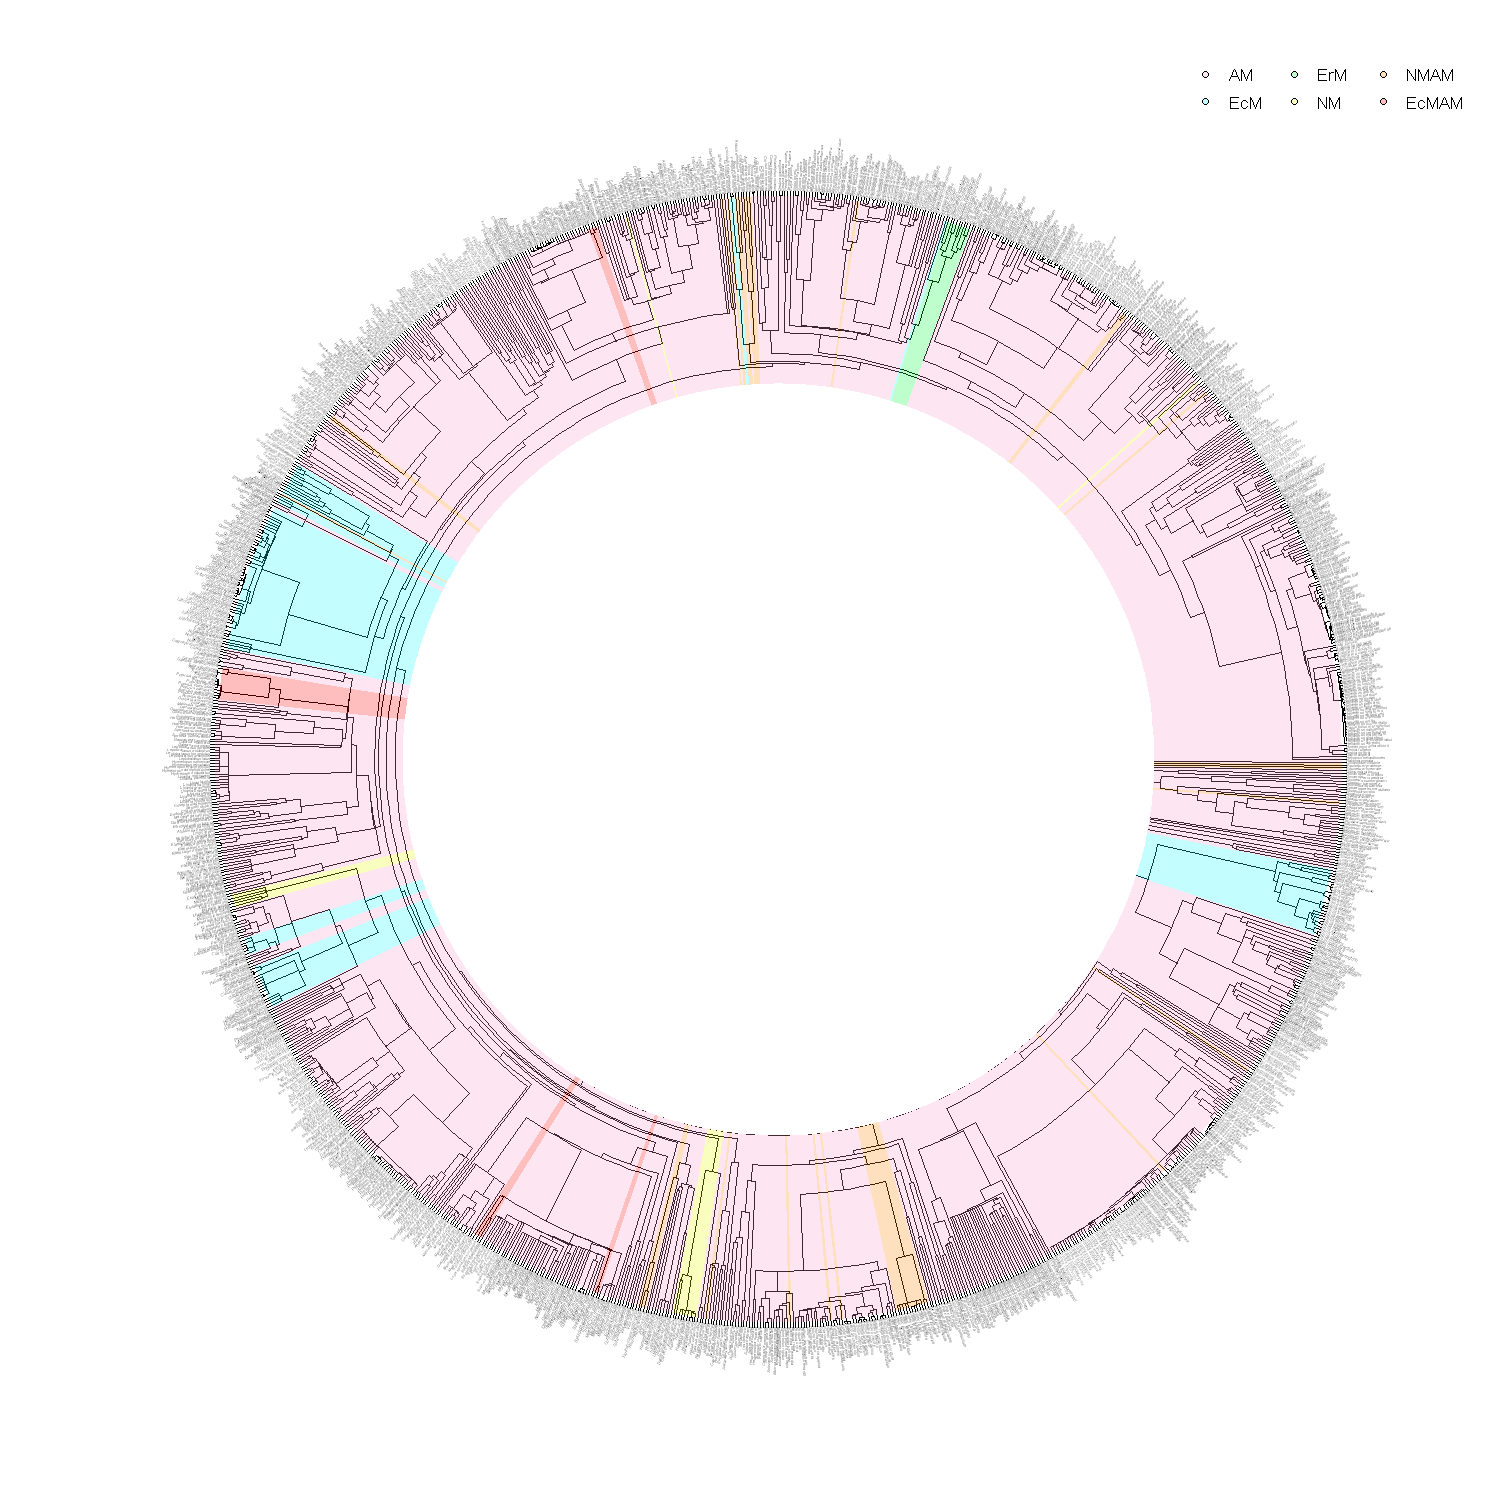

In [10]:
# check if the species and states match in the render

# png("../../plots/state-doughnut.png", width = 20, height = 20, res = 200, units = "in")
par(mar = c(1, 4, 2, 1), oma = c(0, 0, 0, 0))
ape::plot.phylo(x = phylogeny, lwd = 1, type = "fan", show.tip.label = TRUE, show.node.label = FALSE, cex = 0.25)

doughnut((rle(data$state)$length / 1301), inner.radius=0.6, outer.radius=0.9, col=STATE_COLOURS[rle(data$state)$values], init.angle = -0.15)
legend("topright", legend = names(STATE_COLOURS), pt.bg = STATE_COLOURS, pch = 21, pt.cex = 1, horiz = FALSE, ncol = 3, bty = "n", y.intersp = 0.6, x.intersp = 0.7, text.width = 0.05)

# dev.off()

In [14]:
data[data$state == "EcM", "binominal"][1:20, ]

binominal
<chr>
Arbutus_unedo
Coccoloba_manzinellensis
Coccoloba_excelsa
Carpinus_caroliniana
Carpinus_betulus
Carpinus_cordata
Corylus_ferox
Corylus_sieboldiana
Betula_pendula


In [52]:
png("../../plots/phylogeny__.png", width = 22, height = 22, res = 500, units = "in", type = "cairo-png") # cairo-png is wayyy faster than the default png device
# changing the devices - jpeg, bmp did not help with the cropping issue
# par(omi = c(0, 0, 0, 0), # outer margins aren't the issue here
#     mai = c(1, 1, 1, 1)
#     # plt = c(1, 1, 1, 1)
# )
par(mai = c(2, 1, 2, 1), pin = c(20, 20))

doughnut((rle(data$state)$length / 1301), inner.radius=0.75, outer.radius=1.0, col=STATE_COLOURS[rle(data$state)$values], init.angle = -0.15, new = TRUE)
par(new=TRUE) # this will prevent ape::plot.phylo() from drawing a new plot
ape::plot.phylo(x = phylogeny, lwd = 1, type = "fan", show.tip.label = FALSE, show.node.label = FALSE, no.margin = FALSE)

SPACING_FIRST <- 8
ape::tiplabels(bg = "red", pch = 21, cex = scale(exp(data$F00679)), offset = SPACING_FIRST)
ape::tiplabels(bg = "blue", pch = 21, cex = scale(exp(data$F00727)) / 1.5, offset = SPACING_FIRST + 14)
ape::tiplabels(bg = "orange", pch = 21, cex = scale(exp(data$F00709)) / 1.5, offset = SPACING_FIRST + 28)


legend("topright", legend = names(STATE_COLOURS), pt.bg = STATE_COLOURS, pch = 22, pt.cex = 3, horiz = FALSE, ncol = 2, bty = "n", y.intersp = 1.2, x.intersp = 1.2, text.width = 0.05)
legend("bottomright", legend = c("RD", "SRL", "RTD"), pt.bg = c("red", "blue", "orange"), pch = 21, pt.cex = 3, horiz = FALSE, ncol = 3, bty = "n", x.intersp = 1.2, text.width = 0.05)

dev.off()

Warning message in rep(lty, length.out = nx):
"'x' is NULL so the result will be NULL"
Warning message in rep(density, length.out = nx):
"'x' is NULL so the result will be NULL"


pdf 
  2

In [ ]:
# an important note here is that it is not the phylogeny that's getting cropped - it's the markers around the perimeter
# since this shit ain't working, first plot and save the phylogeny and the doughnut first as a PNG
# then save the markers and the legend as another PNG with transparent background
# and finally overlay the second on top of the first, using GIMP???

In [47]:
# phylogeny, doughnut and legends
png("../../plots/phylogeny.png", width = 22, height = 22, res = 800, units = "in", type = "cairo-png")
doughnut((rle(data$state)$length / 1301), inner.radius=0.75, outer.radius=1.0, col=STATE_COLOURS[rle(data$state)$values], init.angle = -0.15, new = TRUE)
par(new=TRUE)
ape::plot.phylo(x = phylogeny, lwd = 1, type = "fan", show.tip.label = FALSE, show.node.label = FALSE, no.margin = FALSE)
legend("topright", legend = names(STATE_COLOURS), pt.bg = STATE_COLOURS, pch = 22, pt.cex = 4, horiz = FALSE, ncol = 2, bty = "n", y.intersp = 1.6, x.intersp = 1.4, text.width = 22)
legend("bottomright", legend = c("RD", "SRL", "RTD"), pt.bg = c("red", "blue", "orange"), pch = 21, pt.cex = 4, horiz = FALSE, ncol = 3, bty = "n", x.intersp = 1.4, text.width = 18)
dev.off()

Warning message in rep(lty, length.out = nx):
"'x' is NULL so the result will be NULL"
Warning message in rep(density, length.out = nx):
"'x' is NULL so the result will be NULL"


pdf 
  2

In [49]:
# perimeter markers for RD and SRL
png("../../plots/perimeter_RD_SLR.png", width = 22, height = 22, res = 800, units = "in", type = "cairo-png", bg = "transparent")
plot.new()
ape::plot.phylo(x = phylogeny, lwd = 1, type = "fan", show.tip.label = FALSE, show.node.label = FALSE, plot = FALSE)

SPACING_FIRST <- 8
ape::tiplabels(bg = "red", pch = 21, cex = scale(exp(data$F00679)), offset = SPACING_FIRST)
ape::tiplabels(bg = "blue", pch = 21, cex = scale(exp(data$F00727)) / 1.5, offset = SPACING_FIRST + 14)
# ape::tiplabels(bg = "orange", pch = 21, cex = scale(exp(data$F00709)) / 1.5, offset = SPACING_FIRST + 28)

dev.off()

pdf 
  2

In [51]:
# perimeter markers for RTD
png("../../plots/perimeter_RTD.png", width = 22, height = 22, res = 800, units = "in", type = "cairo-png", bg = "transparent")
plot.new()
ape::plot.phylo(x = phylogeny, lwd = 1, type = "fan", show.tip.label = FALSE, show.node.label = FALSE, plot = FALSE)

SPACING_FIRST <- 8
ape::tiplabels(bg = "orange", pch = 21, cex = scale(exp(data$F00709)) / 1.5, offset = SPACING_FIRST + 14)

dev.off()

pdf 
  2

Warning message in rep(lty, length.out = nx):
"'x' is NULL so the result will be NULL"
Warning message in rep(density, length.out = nx):
"'x' is NULL so the result will be NULL"


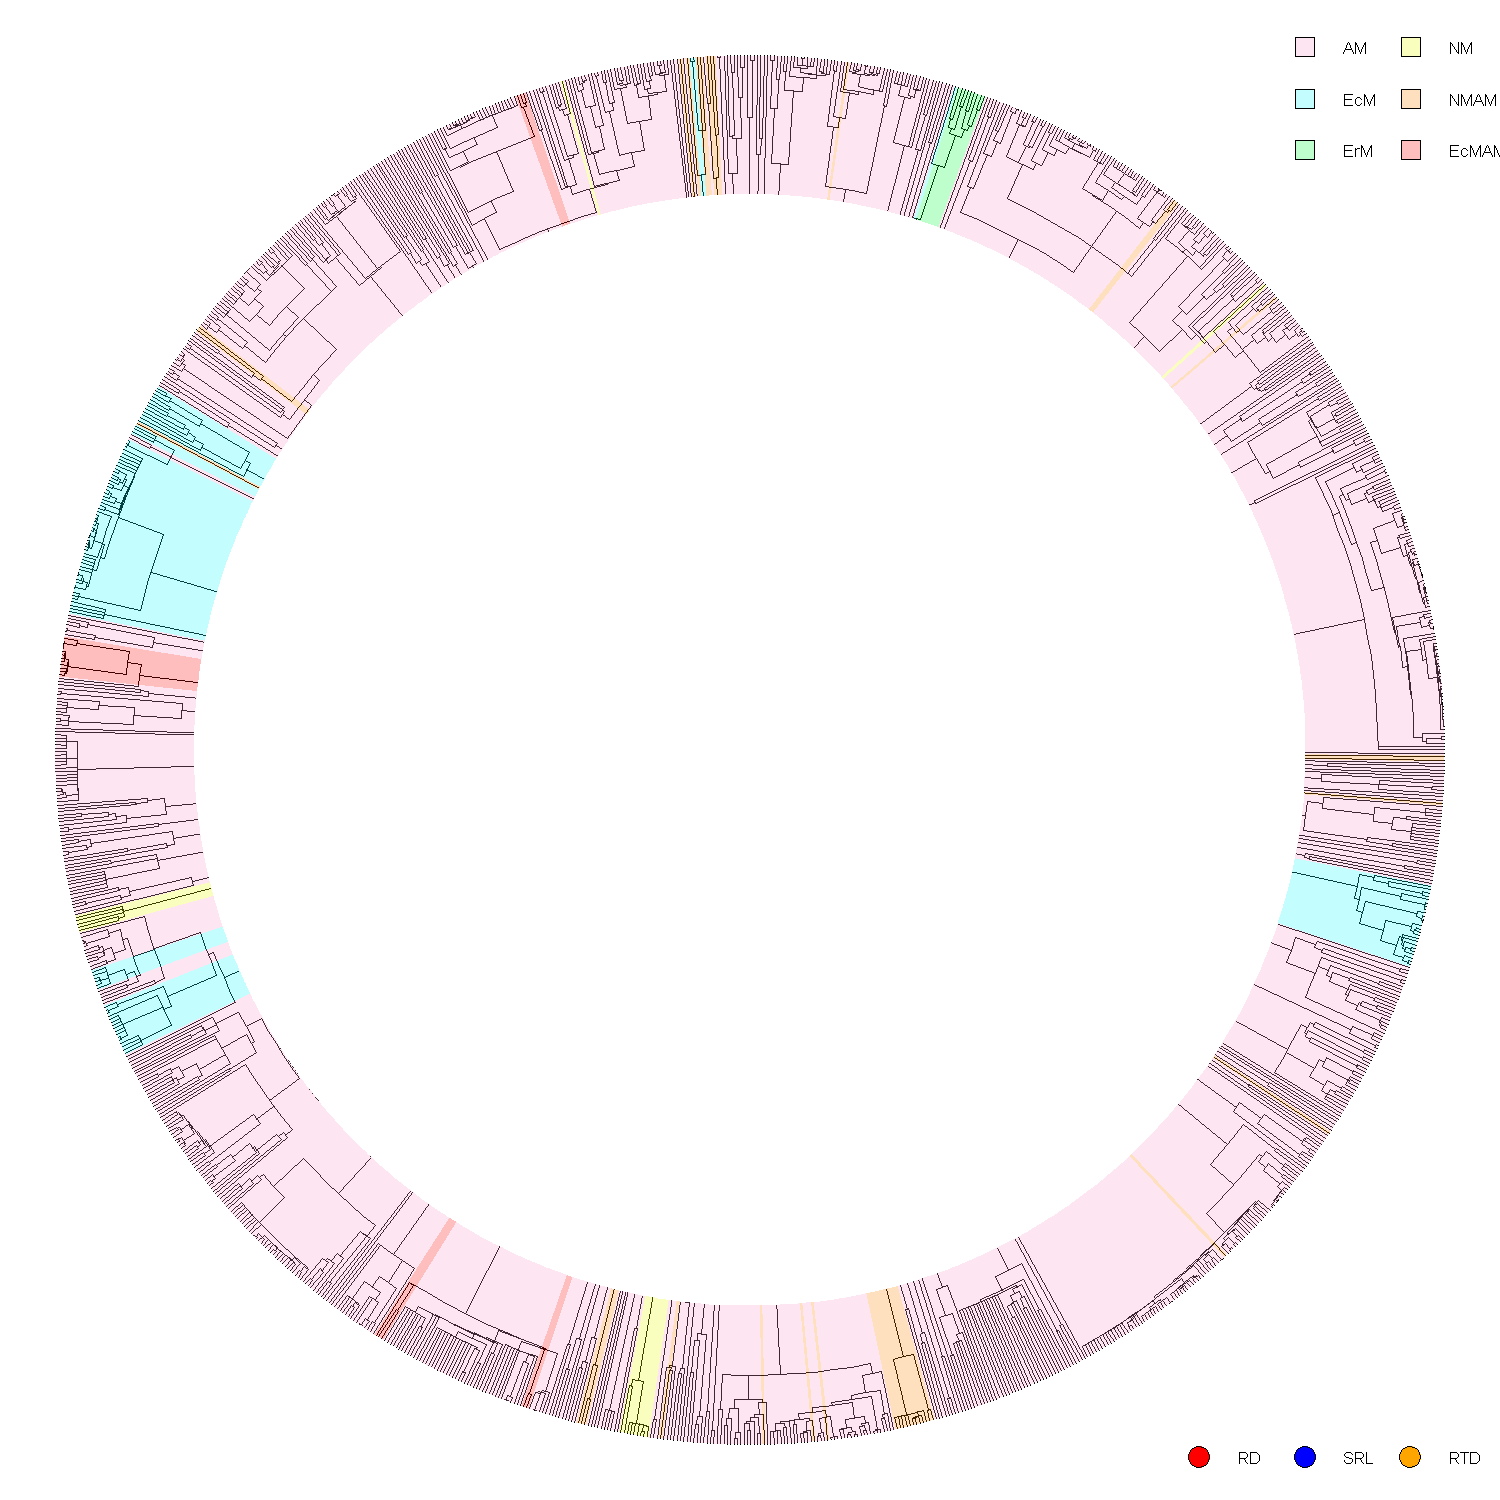

In [47]:
par(omi = c(0, 0, 0, 0), # outer margins aren't the issue here
    mai = c(0, 0, 0, 0))


ape::plot.phylo(x = phylogeny, lwd = 1, type = "fan", show.tip.label = FALSE, show.node.label = FALSE)
doughnut((rle(data$state)$length / 1301), inner.radius=0.8, outer.radius=1.0, col=STATE_COLOURS[rle(data$state)$values], init.angle = -0.15)

SPACING_FIRST <- 8
ape::tiplabels(bg = "red", pch = 21, cex = scale(exp(data$F00679)), offset = SPACING_FIRST)
ape::tiplabels(bg = "blue", pch = 21, cex = scale(exp(data$F00727)) / 1.5, offset = SPACING_FIRST + 14)
ape::tiplabels(bg = "orange", pch = 21, cex = scale(exp(data$F00709)) / 1.5, offset = SPACING_FIRST + 28)


legend("topright", legend = names(STATE_COLOURS), pt.bg = STATE_COLOURS, pch = 22, pt.cex = 3, horiz = FALSE, ncol = 2, bty = "n", y.intersp = 1.2, x.intersp = 1.2, text.width = 0.05)
legend("bottomright", legend = c("RD", "SRL", "RTD"), pt.bg = c("red", "blue", "orange"), pch = 21, pt.cex = 3, horiz = FALSE, ncol = 3, bty = "n", x.intersp = 1.2, text.width = 0.05)

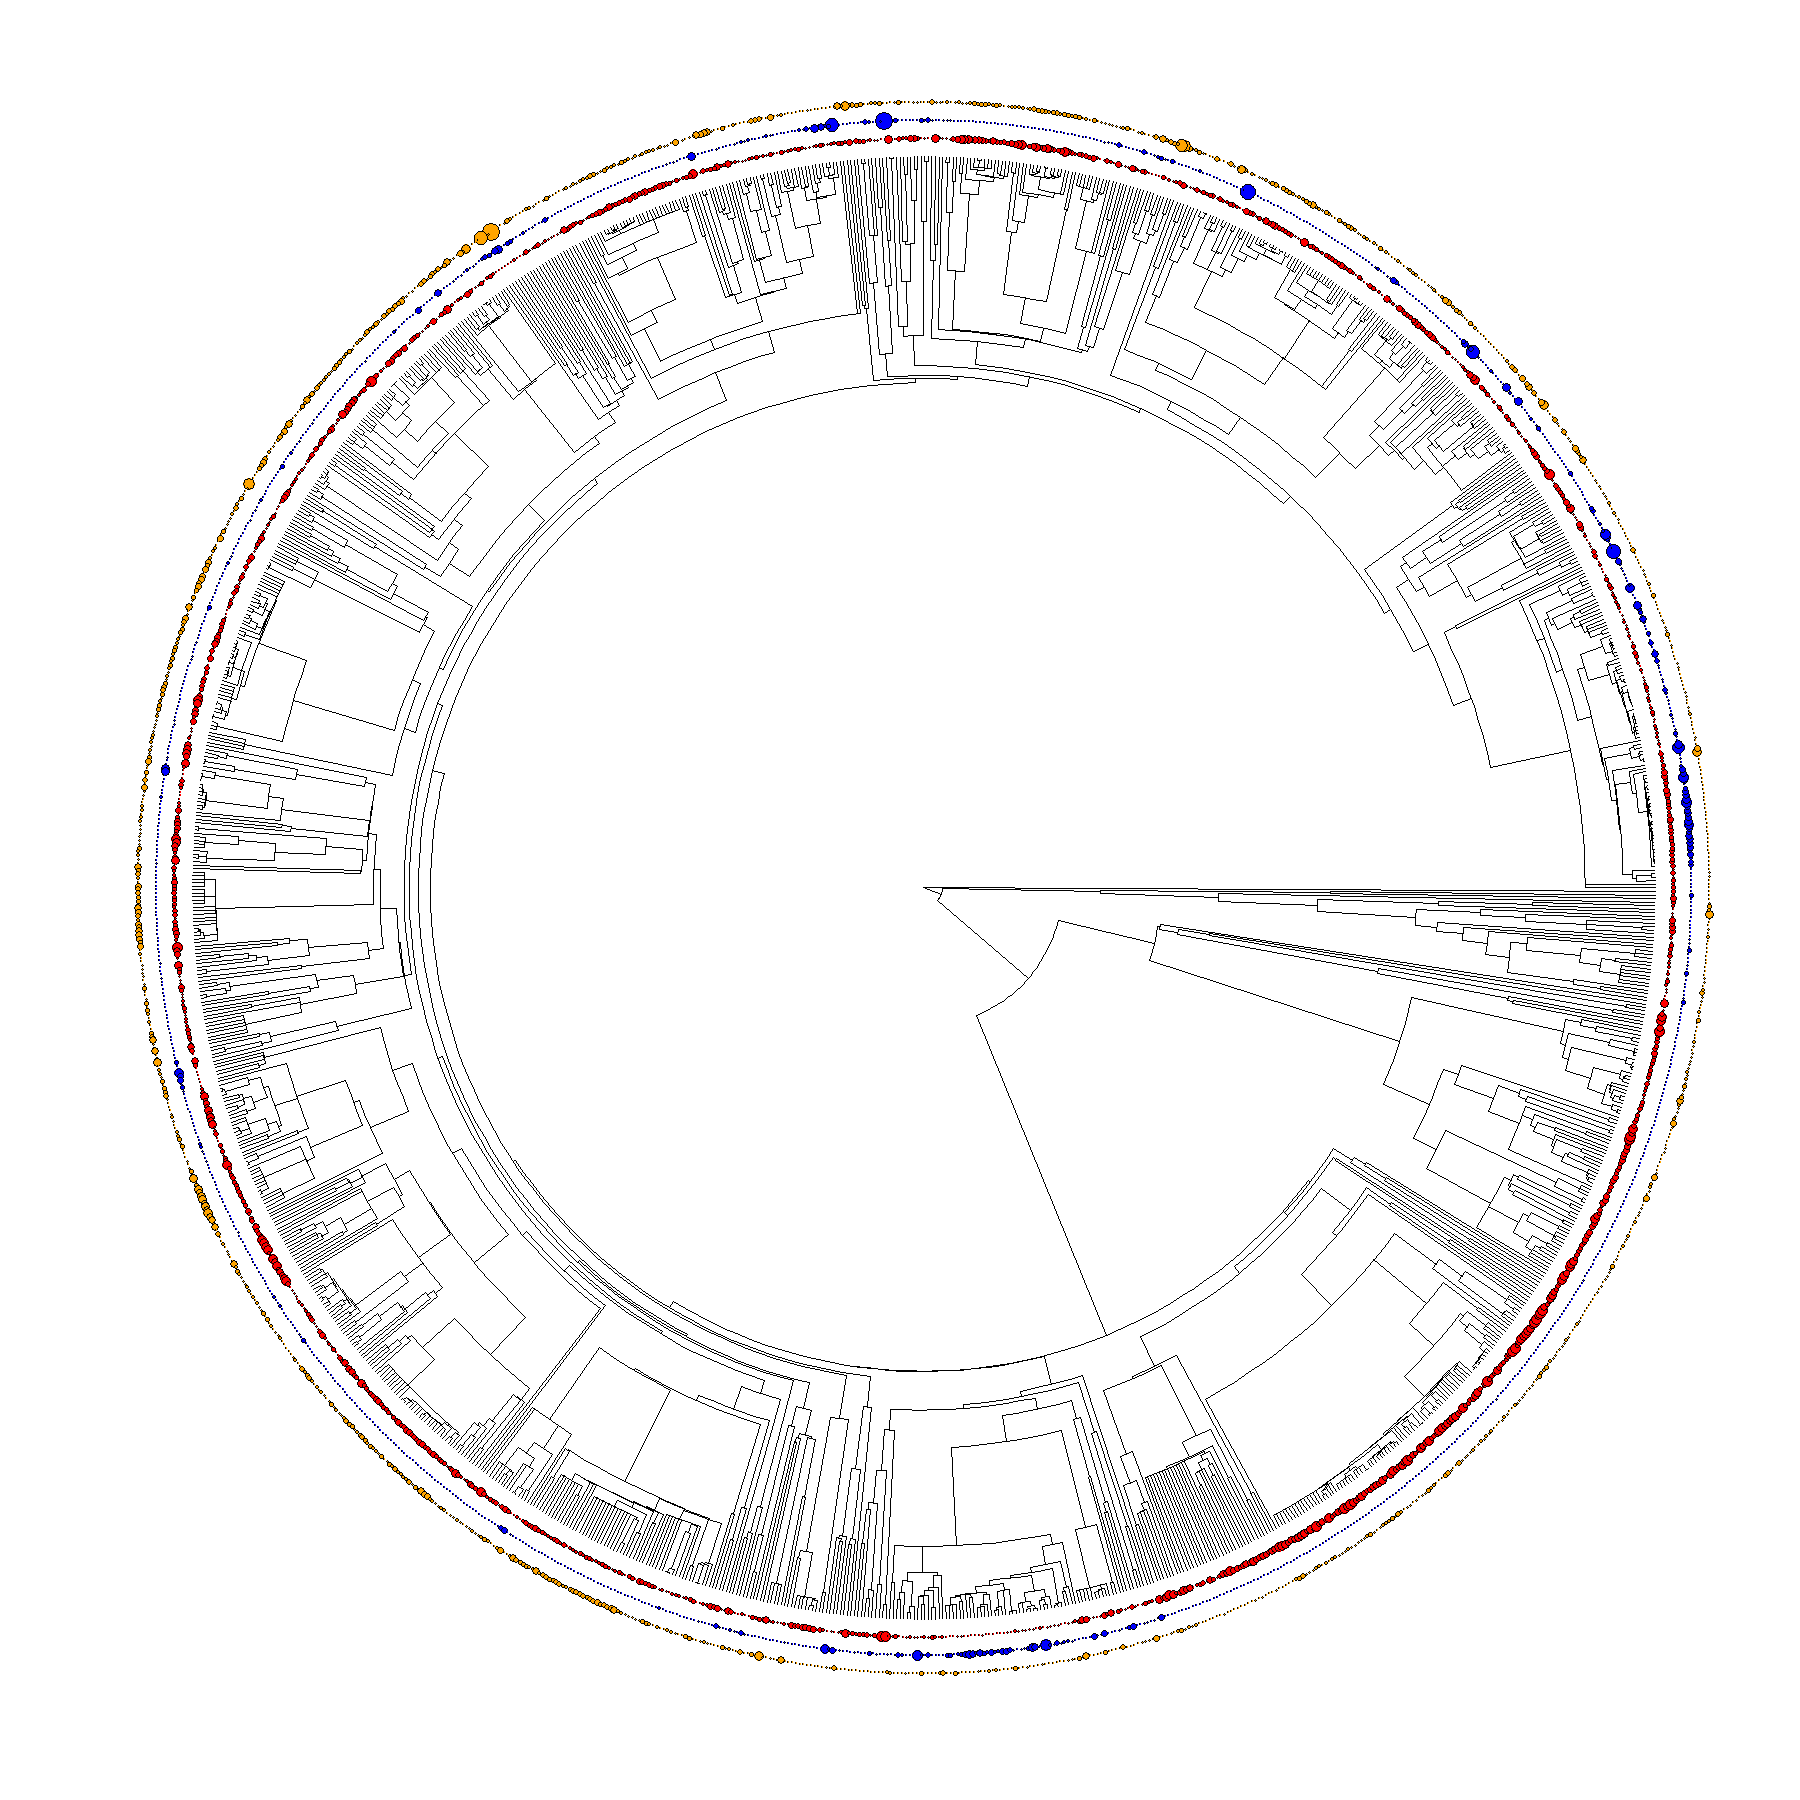

In [23]:
options(repr.plot.width = 15, repr.plot.height = 15)
ape::plot.phylo(x = phylogeny, lwd = 1, type = "fan", show.tip.label = FALSE, show.node.label = FALSE)

SPACING_FIRST <- 10.0

# if we want to see all the species set center to FALSE
ape::tiplabels(bg = "red", pch = 21, cex = exp(data$F00679) / max(exp(data$F00679)) * 1.25, offset = SPACING_FIRST) # RD
ape::tiplabels(bg = "blue", pch = 21, cex = exp(data$F00727) / max(exp(data$F00727)) * 2, offset = SPACING_FIRST + 10) # SRL
ape::tiplabels(bg = "orange", pch = 21, cex = exp(data$F00709) / max(exp(data$F00709)) * 2, offset = SPACING_FIRST + 20) # RTD

In [8]:
# create a family and order mapped phylogeny so we could anchor representative silhouettes around the perimeter
# the classifications in this lookup table isn't perfect but will be good enough for this purpose

lookup = read.csv("../../data/chapter2/plantlookup_serialized_from_r.csv")
head(lookup)

,genus,family,order,group
,<chr>,<chr>,<chr>,<chr>
1,Acorus,Acoraceae,Acorales,Angiosperms
2,Albidella,Alismataceae,Alismatales,Angiosperms
3,Alisma,Alismataceae,Alismatales,Angiosperms
4,Astonia,Alismataceae,Alismatales,Angiosperms
5,Baldellia,Alismataceae,Alismatales,Angiosperms
6,Burnatia,Alismataceae,Alismatales,Angiosperms


In [24]:
setdiff(unique(data$F01289), lookup$family) # not that bad - just 3 families

[1] "Viburnaceae"     "Nyssaceae"       "Cephalotaxaceae"

In [32]:
higher_taxa <- lookup[unique(data$F01289) %in% lookup$family, c("family", "order", "group")]
higher_taxa <- higher_taxa[!duplicated(higher_taxa$family), ]

In [34]:
higher_taxa |> head(10)

,family,order,group
,<chr>,<chr>,<chr>
1,Acoraceae,Acorales,Angiosperms
2,Alismataceae,Alismatales,Angiosperms
19,Aponogetonaceae,Alismatales,Angiosperms
21,Araceae,Alismatales,Angiosperms
143,Butomaceae,Alismatales,Angiosperms
144,Cymodoceaceae,Alismatales,Angiosperms
149,Hydrocharitaceae,Alismatales,Angiosperms
167,Juncaginaceae,Alismatales,Angiosperms
172,Posidoniaceae,Alismatales,Angiosperms


In [58]:
classification <- merge(data, lookup, by.x = "F01286", by.y = "genus", all.x = TRUE)[, c("binominal", "F01286", "F01289", "family", "order")]
classification <- classification[match(phylogeny$tip.label, classification$binominal), ] # name match the phylogeny
head(classification)

,binominal,F01286,F01289,family,order
,<chr>,<chr>,<chr>,<chr>,<chr>
1089,Ratibida_pinnata,Ratibida,Asteraceae,Asteraceae,Asterales
568,Heliopsis_helianthoides,Heliopsis,Asteraceae,Asteraceae,Asterales
671,Liatris_aspera,Liatris,Asteraceae,Asteraceae,Asterales
110,Arnica_sororia,Arnica,Asteraceae,Asteraceae,Asterales
109,Arnica_fulgens,Arnica,Asteraceae,Asteraceae,Asterales
588,Hymenoxys_richardsonii,Hymenoxys,Asteraceae,Asteraceae,Asterales


In [78]:
png("../../plots/phylogeny_orders.png", width = 22, height = 22, res = 600, units = "in", type = "cairo-png")
doughnut((rle(classification$order)$length / 1301), labels = rle(classification$order)$values, inner.radius=0.8, outer.radius=1.0, init.angle = -0.15, new = TRUE)
par(new=TRUE)
ape::plot.phylo(x = phylogeny, lwd = 1, type = "fan", show.tip.label = FALSE, show.node.label = FALSE)
dev.off()

Warning message in rep(lty, length.out = nx):
"'x' is NULL so the result will be NULL"
Warning message in rep(density, length.out = nx):
"'x' is NULL so the result will be NULL"


pdf 
  2

In [74]:
png("../../plots/phylogeny_tiplabels.png", width = 22, height = 22, res = 600, units = "in", type = "cairo-png")
ape::plot.phylo(x = phylogeny, lwd = 1, type = "fan", cex = 0.3, label.offset = 4)
dev.off()

pdf 
  2

In [83]:
phylopic <- read.csv("../../data/chapter2/PhyloPic_build545_full_catelog.csv")
phylopic$binominal <- gsub(phylopic$binominal, pattern = ' ', replacement = '_')

In [91]:
subset_phylopic <- merge(phylopic, classification, by.x = "binominal", by.y = "binominal")

In [107]:
subset_phylopic[subset_phylopic$order == "Laurales", ]

,binominal,url,F01286,F01289,family,order
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
57,Litsea_glutinosa,https://www.phylopic.org/images/1983f288-4843-4b01-be99-3a4f49ae3a13?build=545,Litsea,Lauraceae,Lauraceae,Laurales
94,Sassafras_albidum,https://www.phylopic.org/images/912f8bf1-9b8e-4cc0-a987-df5243dc8c97?build=545,Sassafras,Lauraceae,Lauraceae,Laurales


In [104]:
classification[classification$order == "Apiales", ]

,binominal,F01286,F01289,family,order
,<chr>,<chr>,<chr>,<chr>,<chr>
815,Musineon_divaricatum,Musineon,Apiaceae,Apiaceae,Apiales
1300,Zizia_aurea,Zizia,Apiaceae,Apiaceae,Apiales
1239,Tordylium_maximum,Tordylium,Apiaceae,Apiaceae,Apiales
352,Daucus_carota,Daucus,Apiaceae,Apiaceae,Apiales
1129,Sanicula_orthacantha,Sanicula,Apiaceae,Apiaceae,Apiales
1144,Sciodaphyllum_acuminatum,Sciodaphyllum,Araliaceae,Araliaceae,Apiales
NA,NA,NA,NA,NA,NA
NA.1,NA,NA,NA,NA,NA
1138,Schefflera_digita,Schefflera,Araliaceae,Araliaceae,Apiales
